# Exploring the global_bleaching_environmental Dataset

Capstone research question: Does the relative importance of depth, turbidity, and windspeed in explaining coral bleaching vary across coral reef ecoregions, after accounting for thermal stress?

Outcome: Percent_Bleaching

Region: Ecoregion_Name (filtered to major ones)

Thermal control: SSTA_DHW (Sea Surface Temperature Anomaly – Degree Heating Weeks)

Environmental predictors: Depth_m, Turbidity, Windspeed

## 1: Imports and CSV

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df_og = pd.read_csv('../Code/original_global_bleaching_environmental.csv')
df_cleaned = pd.read_csv('../Code/cleaned_data.csv')

/var/folders/__/qmbrxmxx2q33tz8sl9gxv45c0000gq/T/ipykernel_25135/824813981.py:1: DtypeWarning: Columns (13,15,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df_og = pd.read_csv('../Code/original_global_bleaching_environmental.csv')


## 2: Overview of Dataset

Here I will look at the general information of the dataset.

In [4]:
df_og.head()

,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,nd,Tropical Atlantic,Cuba and Cayman Islands,Cuba,...,5,0,0,0.74,7.25,0.18,2005-09-15,nd,nd,nd
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,nd,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,...,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,nd
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,...,7,0,0,1.04,11.66,0.26,2006-01-15,nd,nd,nd
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,4,0,0,0.75,5.64,0.2,2006-04-15,nd,nd,nd
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,5,0,0,0.92,6.89,0.25,2006-04-15,nd,nd,nd


In [5]:
df_og.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41361 entries, 0 to 41360
Data columns (total 62 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Site_ID                                41361 non-null  int64  
 1   Sample_ID                              41361 non-null  int64  
 2   Data_Source                            41361 non-null  object 
 3   Latitude_Degrees                       41361 non-null  float64
 4   Longitude_Degrees                      41361 non-null  float64
 5   Ocean_Name                             41361 non-null  object 
 6   Reef_ID                                41361 non-null  object 
 7   Realm_Name                             41361 non-null  object 
 8   Ecoregion_Name                         41361 non-null  object 
 9   Country_Name                           41361 non-null  object 
 10  State_Island_Province_Name             41361 non-null  object 
 11  Ci

Above in the .info() we can see the first issue, being that most columns are considered 'objects' and not numeric (int/float). Could prove to be a problem when trying to convert and use it for calculations.

In [6]:
df_og.describe()

,Site_ID,Sample_ID,Latitude_Degrees,Longitude_Degrees,Cyclone_Frequency,Date_Day,Date_Month,Date_Year
count,4.136100e+04,4.136100e+04,41361.000000,41361.000000,41361.000000,41361.000000,41361.000000,41361.000000
mean,7.455816e+04,1.012880e+07,7.558085,34.966127,52.159650,16.037402,6.902686,2007.796765
std,2.520418e+05,1.373151e+06,15.732185,103.404598,7.589593,7.837400,2.875063,6.073043
min,1.000000e+00,9.623000e+03,-30.262500,-179.974300,18.310000,1.000000,1.000000,1980.000000
25%,3.502000e+03,1.031108e+07,-4.902500,-78.385600,47.940000,10.000000,5.000000,2003.000000
50%,5.925000e+03,1.031628e+07,10.776100,96.843300,50.920000,15.000000,7.000000,2007.000000
75%,8.368000e+03,1.032149e+07,20.050500,120.880400,55.730000,22.000000,9.000000,2013.000000
max,1.000060e+06,1.033171e+07,36.750000,179.964500,105.800000,31.000000,12.000000,2020.000000


## 3: Looking into Individual Columns

Here I will look into some Colums that could be useful for my research.

### 3.1: Site_ID & Sample_ID

Neither Site_ID nor Sample_ID seem to have a unique value for each row. Meaning they won't be too useful to identify any outliers.

In [7]:
print(f"Number of samples: {len(df_og['Sample_ID'])}")
print(f"Number of unique samples: {len(df_og['Sample_ID'].unique())}\n")
print(f"Number of sites: {len(df_og['Site_ID'])}")
print(f"Number of unique sites: {len(df_og['Site_ID'].unique())}")

Number of samples: 41361
Number of unique samples: 27005

Number of sites: 41361
Number of unique sites: 12702


### 3.2.1: Geographical Region Columns (Ocean_Name, Realm_Name, Ecoregion_Name, Country_Name)

Here I aim to pick the best geographical identifier. Oceans and Realms seem to have too few unique values. Both Countries and Ecoregions have a good amount of unique values. They also both have a similar distribution of sample sizes in the top 20.

However Ecoregions fits the purpose of this project better as they describe the area of the sites more accurately.

To have a sufficient sample size per Ecoregion I will only be looking at Regions with 1000 or more samples. This would leave 11.

In [8]:
print(f"Number of Oceans: {len(df_og['Ocean_Name'].unique())}\n")
print(f"Number of Realms: {len(df_og['Realm_Name'].unique())}\n")
print(f"Number of Ecoregions: {len(df_og['Ecoregion_Name'].unique())}\n")
print(f"Number of Countries: {len(df_og['Country_Name'].unique())}")

Number of Oceans: 5

Number of Realms: 9

Number of Ecoregions: 115

Number of Countries: 91


In [9]:
df_og["Ecoregion_Name"].value_counts().head(20)

Ecoregion_Name
Bahamas and Florida Keys                      4227
Belize and west Caribbean                     4001
Hispaniola Puerto Rico and Lesser Antilles    2971
Sunda Shelf south-east Asia                   2496
Sulu Sea                                      2339
Central and northern Great Barrier Reef       1613
South-east Philippines                        1396
North and central Red Sea                     1339
Society Islands French Polynesia              1315
Fiji                                          1262
Jamaica                                       1153
Cuba and Cayman Islands                        992
South Vietnam                                  965
Lesser Sunda Islands and Savu Sea              852
New Caledonia                                  852
Gulf of Thailand                               843
Banda Sea and Molucca Islands                  797
Maldive Islands                                784
Netherlands Antilles and south Caribbean       761
Hong Kong       

In [10]:
df_og["Country_Name"].value_counts().head(20)

Country_Name
United States           4611
Malaysia                4581
Australia               2956
Indonesia               2923
Mexico                  2151
Philippines             1911
French Polynesia        1418
Vietnam                 1390
Fiji                    1262
Japan                   1253
Egypt                   1216
Jamaica                 1153
Cuba                     924
New Caledonia            852
Belize                   824
Maldives                 782
China                    752
Bahamas                  711
Taiwan                   680
Netherlands Antilles     677
Name: count, dtype: int64

#### 3.2.2: Dropping all rows from the Ecoregions with <1000 samples

In [11]:
counts = df_og["Ecoregion_Name"].value_counts()

valid_ecoregions = counts[counts >= 1000].index

df_og = df_og[df_og["Ecoregion_Name"].isin(valid_ecoregions)]

### 3.3: Possible Environmental Predictor Variables (Distance_to_Shore, Exposure, Turbidity, Cyclone_Frequency, Depth_m)

In [12]:
print(f"Number of unique Distances to Shore: {len(df_og['Distance_to_Shore'].unique())}\n")
print(f"Number of unique Exposures: {len(df_og['Exposure'].unique())}\n")
print(f"Number of unique Turbidities: {len(df_og['Turbidity'].unique())}\n")
print(f"Number of unique Cyclone Frequencies: {len(df_og['Cyclone_Frequency'].unique())}\n")
print(f"Number of unique Depths: {len(df_og['Depth_m'].unique())}\n")
print(f"Number of unique Wind Speeds: {len(df_og['Windspeed'].unique())}")

Number of unique Distances to Shore: 7947

Number of unique Exposures: 3

Number of unique Turbidities: 1581

Number of unique Cyclone Frequencies: 902

Number of unique Depths: 457

Number of unique Wind Speeds: 14


#### Distance to Shore

First the values need to be turned into numeric instead object. Considering there are only 2 rows with NaN they can just be dropped.

In [13]:
df_og["Distance_to_Shore"] = pd.to_numeric(df_og["Distance_to_Shore"], errors="coerce")

print(df_og["Distance_to_Shore"].isna().sum())

df_og = df_og.dropna(subset=["Distance_to_Shore"])

print(df_og["Distance_to_Shore"].isna().sum())

2
0


After plotting a Histogram we can see most values are below 250, though there are values up to 300000.

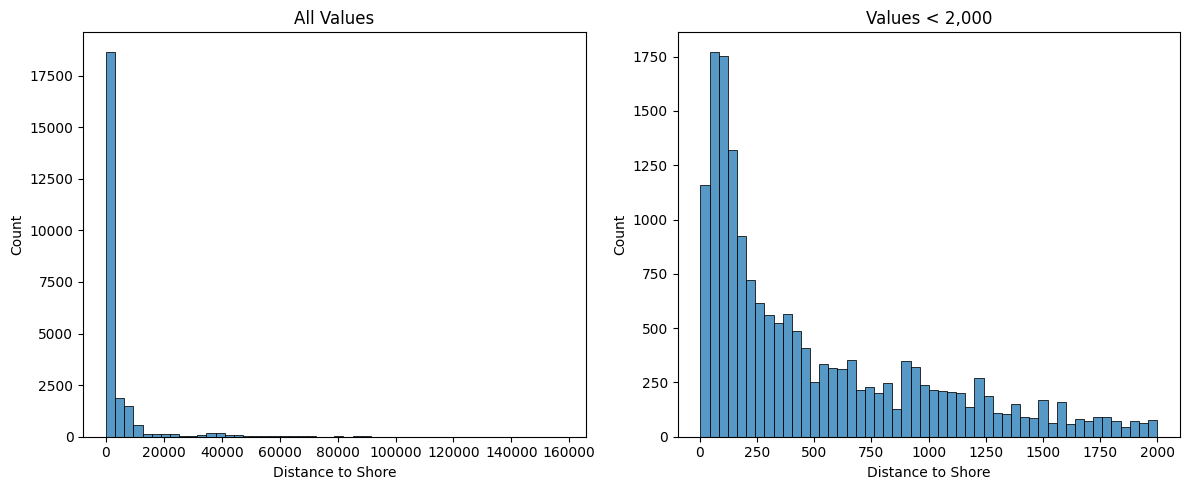

In [14]:

df_filtered = df_og[df_og["Distance_to_Shore"] < 2000]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original
sns.histplot(df_og["Distance_to_Shore"], bins=50, ax=axes[0])
axes[0].set_title("All Values")
axes[0].set_xlabel("Distance to Shore")

# Filtered
sns.histplot(df_filtered["Distance_to_Shore"], bins=50, ax=axes[1])
axes[1].set_title("Values < 2,000")
axes[1].set_xlabel("Distance to Shore")

plt.tight_layout()
plt.show()

#### Exposure

I am mapping exposure to be a numeric value for later calculations

In [15]:
df_og["Exposure"] = df_og["Exposure"].map({
    "Sheltered": 0,
    "Sometimes": 1,
    "Exposed": 2
})

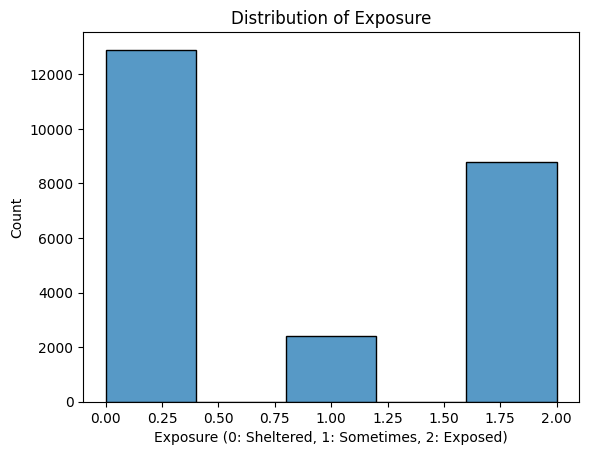

In [16]:
plt.figure()
sns.histplot(df_og["Exposure"], bins=5)
plt.xlabel("Exposure (0: Sheltered, 1: Sometimes, 2: Exposed)")
plt.ylabel("Count")
plt.title("Distribution of Exposure")
plt.show()

#### Turbidity

Again there are only 3 NaN values, so they can just be dropped.

In [17]:
df_og["Turbidity"] = pd.to_numeric(df_og["Turbidity"], errors="coerce")

print(df_og["Turbidity"].isna().sum())

df_og = df_og.dropna(subset=["Turbidity"])

print(df_og["Turbidity"].isna().sum())

3
0


Similar to the Distance_to_Shore variable Turbidity also has most of its values on the lower end of the scale with a few high outliers

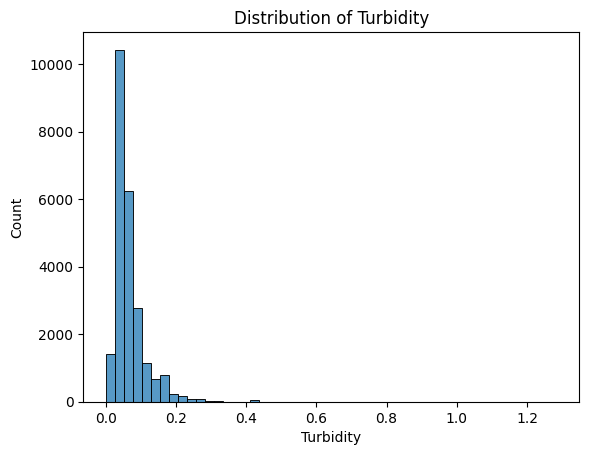

In [18]:
plt.figure()
sns.histplot(df_og["Turbidity"], bins=50)
plt.xlabel("Turbidity")
plt.ylabel("Count")
plt.title("Distribution of Turbidity")
plt.show()

#### Cyclone_Frequency

No missing values here after conversion

In [19]:
df_og["Cyclone_Frequency"] = pd.to_numeric(df_og["Cyclone_Frequency"], errors="coerce")

print(df_og["Cyclone_Frequency"].isna().sum())

0


This is much closer to a normal distribution

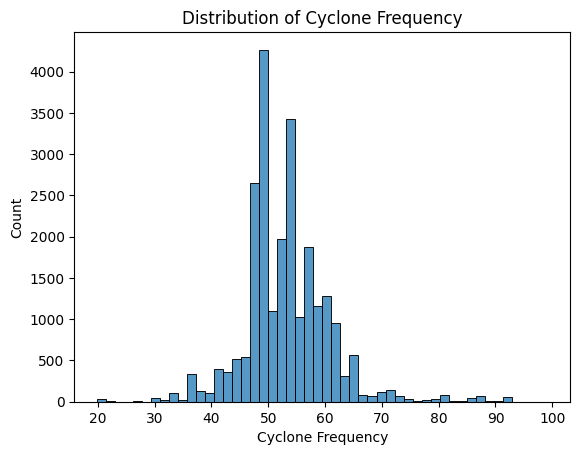

In [20]:
plt.figure()
sns.histplot(df_og["Cyclone_Frequency"], bins=50)
plt.xlabel("Cyclone Frequency")
plt.ylabel("Count")
plt.title("Distribution of Cyclone Frequency")
plt.show()

#### Depth_m

Depth has more NaN values after the numeric conversion (783). These come from the being "nd" values in the data not from problems during conversion.

In [21]:
df_og["Depth_m"] = pd.to_numeric(df_og["Depth_m"], errors="coerce")

print(df_og["Depth_m"].isna().sum())

df_og = df_og.dropna(subset=["Depth_m"])

print(df_og["Depth_m"].isna().sum())

783
0


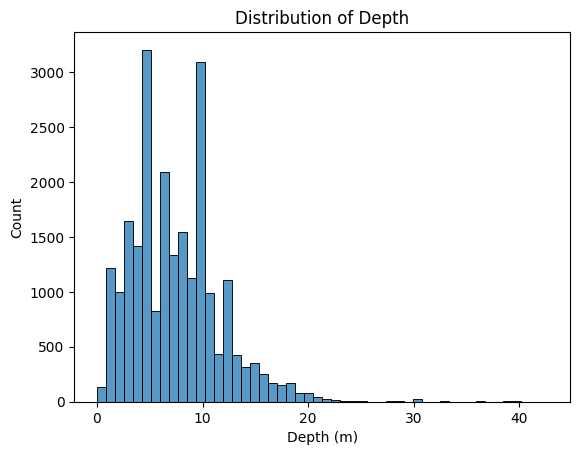

In [22]:
plt.figure()
sns.histplot(df_og["Depth_m"], bins=50)
plt.xlabel("Depth (m)")
plt.ylabel("Count")
plt.title("Distribution of Depth")
plt.show()

#### Windspeed

In [23]:
df_og["Windspeed"] = pd.to_numeric(df_og["Windspeed"], errors="coerce")

print(df_og["Windspeed"].isna().sum())

57


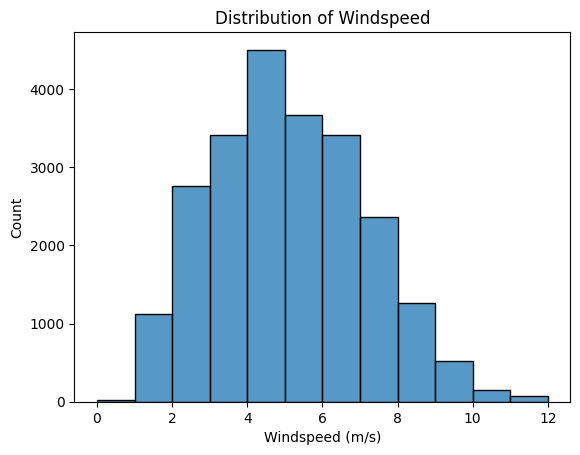

In [24]:
plt.figure()
sns.histplot(df_og["Windspeed"], bins=12)
plt.xlabel("Windspeed (m/s)")
plt.ylabel("Count")
plt.title("Distribution of Windspeed")
plt.show()

### 3.4: Outcome Variable (Percent_Bleaching)

In [25]:
print(f"Number of unique Bleaching Percentages: {len(df_og['Percent_Bleaching'].unique())}")

Number of unique Bleaching Percentages: 2091


Percent_Bleaching also has a lot of NaN values (2133). These also come from "nd" values within the dataset.

In [26]:
df_og["Percent_Bleaching"] = pd.to_numeric(df_og["Percent_Bleaching"], errors="coerce")

print(df_og["Percent_Bleaching"].isna().sum())

df_og = df_og.dropna(subset=["Percent_Bleaching"])

print(df_og["Percent_Bleaching"].isna().sum())

2133
0


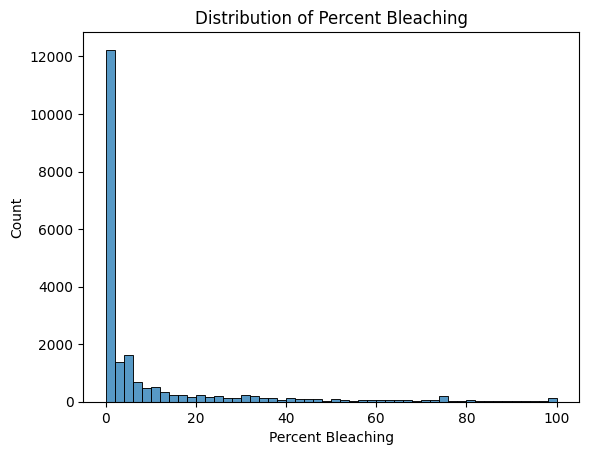

In [27]:
plt.figure()
sns.histplot(df_og["Percent_Bleaching"], bins=50)
plt.xlabel("Percent Bleaching")
plt.ylabel("Count")
plt.title("Distribution of Percent Bleaching")
plt.show()

### 3.5: Control Variable (SSTA_DHW)

In [28]:
print(f"Number of unique SSTA DHW values: {len(df_og['SSTA_DHW'].unique())}")

Number of unique SSTA DHW values: 1246


SSTA_DHW only has 51 missing values which shouldn't be a significant issue.

In [29]:
df_og["SSTA_DHW"] = pd.to_numeric(df_og["SSTA_DHW"], errors="coerce")

print(df_og["SSTA_DHW"].isna().sum())

df_og = df_og.dropna(subset=["SSTA_DHW"])

print(df_og["SSTA_DHW"].isna().sum())

51
0


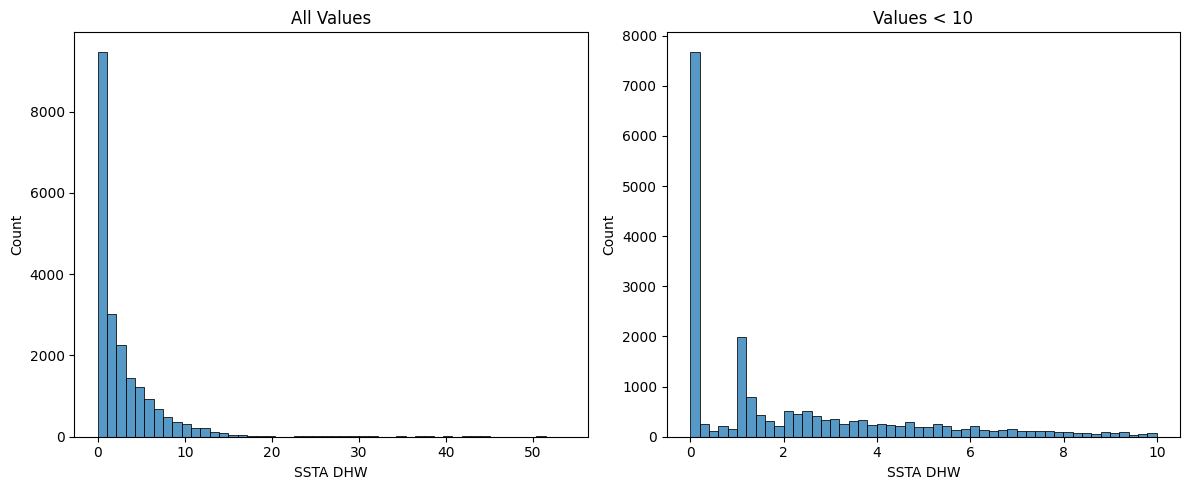

In [30]:
df_filtered = df_og[df_og["SSTA_DHW"] < 10]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original
sns.histplot(df_og["SSTA_DHW"], bins=50, ax=axes[0])
axes[0].set_title("All Values")
axes[0].set_xlabel("SSTA DHW")

# Filtered
sns.histplot(df_filtered["SSTA_DHW"], bins=50, ax=axes[1])
axes[1].set_title("Values < 10")
axes[1].set_xlabel("SSTA DHW")

plt.tight_layout()
plt.show()

## 4: Selecting Important Columns

Here I will filter out all the colums that will not be necessary for my research. The necessary and useful colums include: 

Outcome: Percent_Bleaching

Region: Ecoregion_Name (filtered to major ones >1000 samples)

Thermal control: SSTA_DHW (Sea Surface Temperature Anomaly – Degree Heating Weeks)

Environmental predictors: Distance_to_Shore, Exposure, Turbidity, Cyclone_Frequency, Depth_m, Windspeed

In [31]:
columns_needed = [
    "Ecoregion_Name",
    "Distance_to_Shore",
    "Exposure",
    "Turbidity",
    "Cyclone_Frequency",
    "Depth_m",
    "Windspeed",
    "SSTA_DHW",
    "Percent_Bleaching"
]

df_og = df_og[columns_needed]

In [32]:
df_og.head()

,Ecoregion_Name,Distance_to_Shore,Exposure,Turbidity,Cyclone_Frequency,Depth_m,Windspeed,SSTA_DHW,Percent_Bleaching
1,Society Islands French Polynesia,1431.62,2,0.0262,51.20,14.00,2.0,0.26,50.7
2,Hispaniola Puerto Rico and Lesser Antilles,182.33,2,0.0429,61.52,7.00,8.0,0.00,50.9
3,Hispaniola Puerto Rico and Lesser Antilles,313.13,2,0.0424,65.39,9.02,3.0,0.00,50.9
4,Hispaniola Puerto Rico and Lesser Antilles,792.00,2,0.0424,65.39,12.50,3.0,0.00,50.9
6,Hispaniola Puerto Rico and Lesser Antilles,2399.36,2,0.0372,65.39,27.70,6.0,11.61,51.3


In [33]:
len(df_og["Ecoregion_Name"].unique())

11

## 5: The interaction of the Columns

### Correlation Matrix

This matrix shows that the relationships are non-linear as we know the variables are better predictors than are shown here.

In [34]:
corr = df_og.drop(columns=["Ecoregion_Name"]).corr()

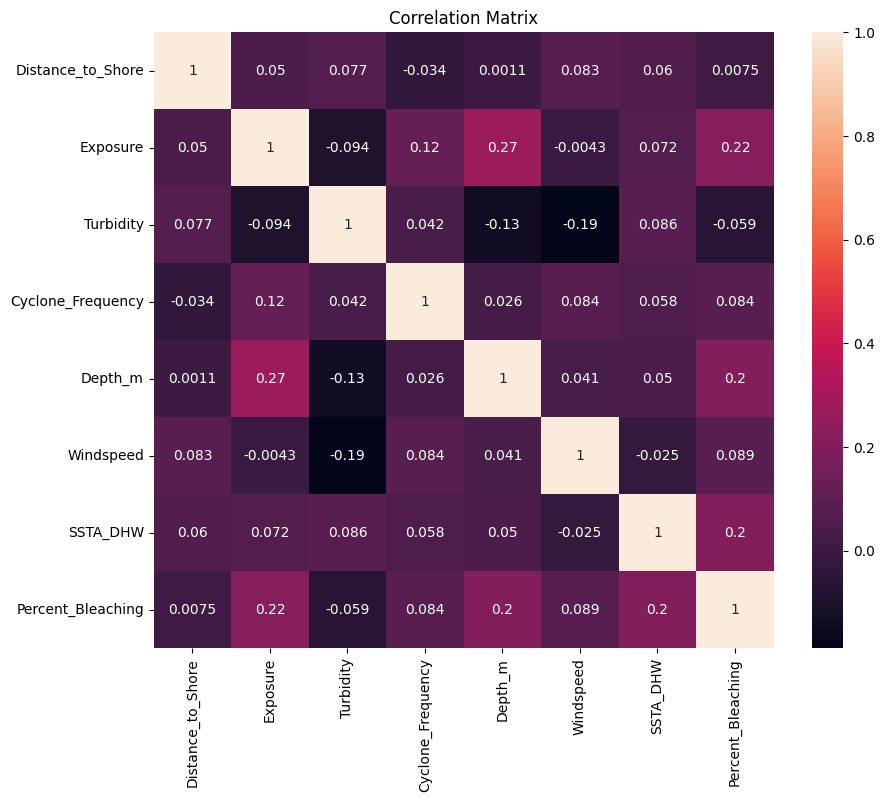

In [35]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

### Bleaching per eco_region

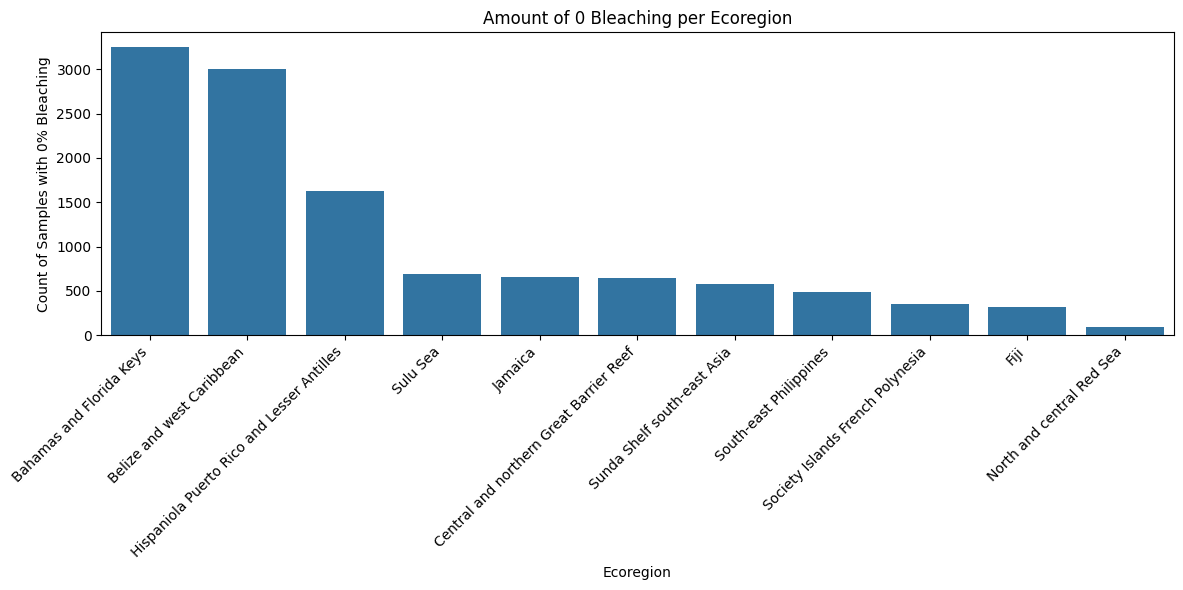

In [36]:
zero_bleaching_df = (
    df_og[df_og["Percent_Bleaching"] != 0]
    .groupby("Ecoregion_Name")
    .size()
    .reset_index(name="Zero_Bleaching_Count")
    .sort_values("Zero_Bleaching_Count", ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=zero_bleaching_df, x="Ecoregion_Name", y="Zero_Bleaching_Count")

plt.title("Amount of 0 Bleaching per Ecoregion")
plt.xlabel("Ecoregion")
plt.ylabel("Count of Samples with 0% Bleaching")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

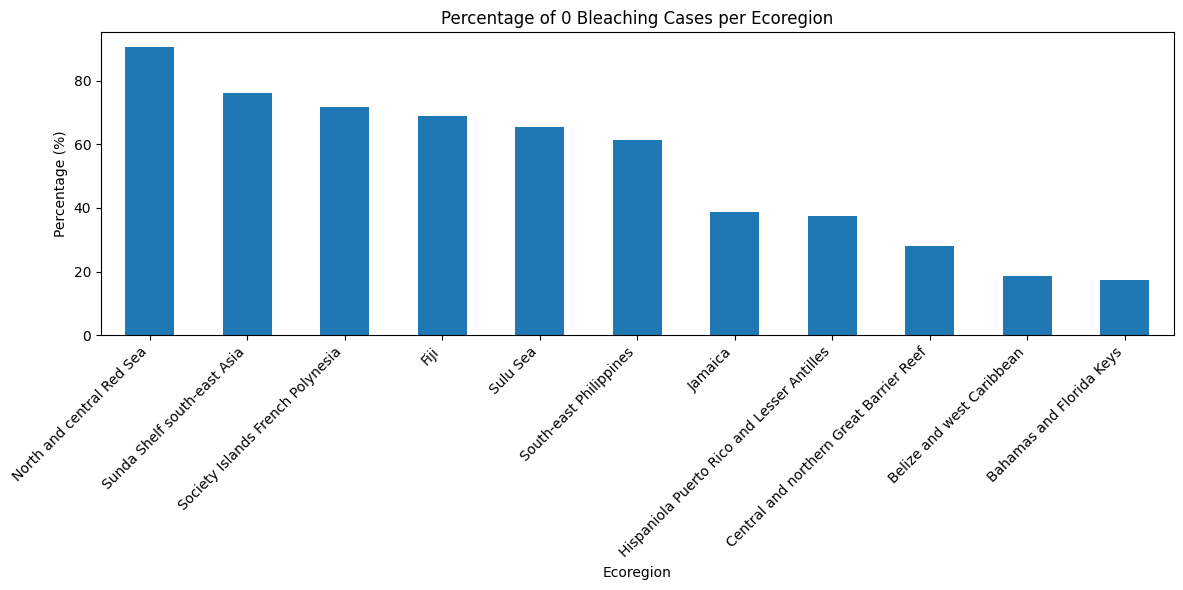

In [37]:
# Total observations per ecoregion
total_counts = df_og.groupby("Ecoregion_Name").size()

# Number of 0-bleaching cases per ecoregion
zero_counts = df_og[df_og["Percent_Bleaching"] == 0] \
    .groupby("Ecoregion_Name") \
    .size()

# Percentage (handle missing with fill_value=0)
zero_percentage = (zero_counts / total_counts * 100).fillna(0).sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
zero_percentage.plot(kind="bar")

plt.title("Percentage of 0 Bleaching Cases per Ecoregion")
plt.xlabel("Ecoregion")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Exploring the Cleaned Data

### Ecoregions that have 500 non-zero Bleaching Readings

In [38]:
ecoregion_counts = df_cleaned["Ecoregion_Name"].value_counts()
ecoregion_counts[ecoregion_counts >= 500]

Ecoregion_Name
Bahamas and Florida Keys                      3256
Belize and west Caribbean                     3006
Hispaniola Puerto Rico and Lesser Antilles    1627
Sulu Sea                                       687
Jamaica                                        658
Central and northern Great Barrier Reef        645
Sunda Shelf south-east Asia                    578
Name: count, dtype: int64

In [55]:
# Count observations by ecoregion
ecoregion_counts = df_cleaned["Ecoregion_Name"].value_counts()
ecoregion_counts = ecoregion_counts[ecoregion_counts >= 500]

# Convert to dataframe
table_df = pd.DataFrame({
    "Ecoregion": ecoregion_counts.index,
    "Observation Count": ecoregion_counts.values
})

# Display styled table
table_df.style.hide(axis="index").set_properties(**{
    "text-align": "center"
}).set_table_styles([
    {
        "selector": "th",
        "props": [
            ("font-size", "18px"),
            ("text-align", "center"),
            ("font-weight", "bold")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("font-size", "16px"),
            ("text-align", "center")
        ]
    }
])

Ecoregion,Observation Count
Bahamas and Florida Keys,3256
Belize and west Caribbean,3006
Hispaniola Puerto Rico and Lesser Antilles,1627
Sulu Sea,687
Jamaica,658
Central and northern Great Barrier Reef,645
Sunda Shelf south-east Asia,578


### Average Bleaching Percentage

In [40]:
avg_bleaching_per_ecoregion = (
    df_cleaned
    .groupby("Ecoregion_Name")["Percent_Bleaching"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_bleaching_per_ecoregion)

Ecoregion_Name
Hispaniola Puerto Rico and Lesser Antilles    29.835648
Belize and west Caribbean                     21.658140
Bahamas and Florida Keys                      16.985187
Jamaica                                        9.725608
Sunda Shelf south-east Asia                    9.661367
Central and northern Great Barrier Reef        8.200744
Sulu Sea                                       6.023290
Name: Percent_Bleaching, dtype: float64


### Average Variable Value per Ecoregion

In [41]:
avg_turbidity_per_ecoregion = (
    df_cleaned
    .groupby("Ecoregion_Name")["Turbidity"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_turbidity_per_ecoregion)

Ecoregion_Name
Sunda Shelf south-east Asia                   0.106512
Central and northern Great Barrier Reef       0.094898
Bahamas and Florida Keys                      0.087649
Sulu Sea                                      0.080326
Hispaniola Puerto Rico and Lesser Antilles    0.050362
Belize and west Caribbean                     0.049560
Jamaica                                       0.039840
Name: Turbidity, dtype: float64


In [42]:
avg_windspeed_per_ecoregion = (
    df_cleaned
    .groupby("Ecoregion_Name")["Windspeed"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_windspeed_per_ecoregion)

Ecoregion_Name
Hispaniola Puerto Rico and Lesser Antilles    6.379226
Jamaica                                       5.889058
Central and northern Great Barrier Reef       5.793798
Belize and west Caribbean                     4.916168
Bahamas and Florida Keys                      4.076167
Sulu Sea                                      3.046579
Sunda Shelf south-east Asia                   2.084775
Name: Windspeed, dtype: float64


In [43]:
avg_depth_per_ecoregion = (
    df_cleaned
    .groupby("Ecoregion_Name")["Depth_m"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_depth_per_ecoregion)

Ecoregion_Name
Hispaniola Puerto Rico and Lesser Antilles    10.688771
Belize and west Caribbean                      9.490502
Jamaica                                        7.910334
Sulu Sea                                       7.896070
Bahamas and Florida Keys                       7.796932
Sunda Shelf south-east Asia                    7.414446
Central and northern Great Barrier Reef        4.714419
Name: Depth_m, dtype: float64


### Looking at the Variable Distributions

#### Percent_Bleaching

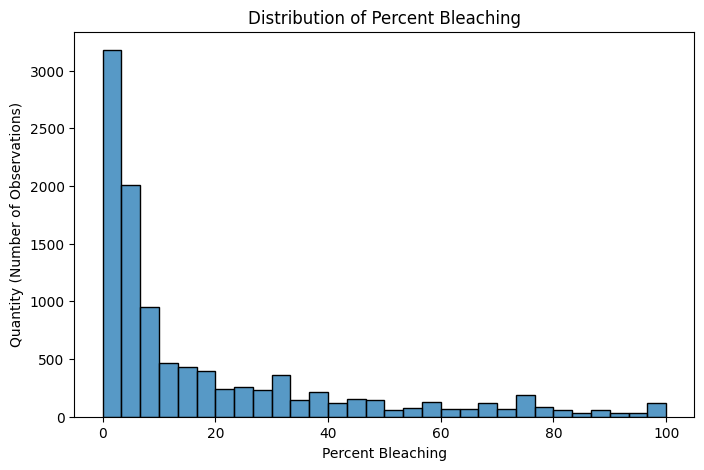

In [44]:
# Distribution of Percent_Bleaching (counts per level)
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned["Percent_Bleaching"], bins=30)

plt.title("Distribution of Percent Bleaching")
plt.xlabel("Percent Bleaching")
plt.ylabel("Quantity (Number of Observations)")

plt.show()

#### SSTA_DHW

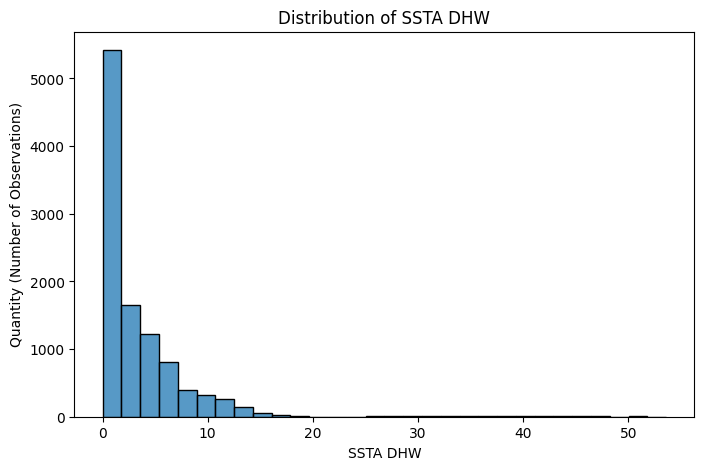

In [45]:
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned["SSTA_DHW"], bins=30)

plt.title("Distribution of SSTA DHW")
plt.xlabel("SSTA DHW")
plt.ylabel("Quantity (Number of Observations)")

plt.show()

### Chat's exploration

#### Outcome Variable

In [46]:
df_cleaned["Percent_Bleaching"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count    10457.000000
mean        18.204259
std         23.428972
min          0.010000
1%           0.250000
5%           0.500000
25%          2.500000
50%          6.780000
75%         25.500000
95%         75.000000
99%         98.000000
max        100.000000
Name: Percent_Bleaching, dtype: float64

#### Year structure

In [47]:
df_cleaned["Date_Year"].value_counts().sort_index()

Date_Year
1987      12
1990       1
1991       2
1992       3
1993       4
1994       3
1995       3
1997       2
1998     112
1999     511
2000     284
2001       3
2002     240
2003     358
2004     277
2005    2571
2006    1352
2007     397
2008     418
2009     538
2010     437
2011     346
2012     311
2013     311
2014     450
2015     515
2016     392
2017     298
2018     108
2019     198
Name: count, dtype: int64

#### Ecoregion X Year

In [48]:
eco_year = pd.crosstab(df_cleaned["Ecoregion_Name"], df_cleaned["Date_Year"])
eco_year

Date_Year,1987,1990,1991,1992,1993,1994,1995,1997,1998,1999,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
Ecoregion_Name,,,,,,,,,,,,,,,,,,,,,
Bahamas and Florida Keys,9,1,2,3,4,3,3,2,45,85,...,268,250,210,114,186,283,186,12,4,2
Belize and west Caribbean,1,0,0,0,0,0,0,0,11,216,...,4,19,14,0,4,0,4,8,12,6
Central and northern Great Barrier Reef,0,0,0,0,0,0,0,0,26,0,...,56,15,17,28,28,36,44,52,0,0
Hispaniola Puerto Rico and Lesser Antilles,1,0,0,0,0,0,0,0,20,210,...,22,16,14,14,20,26,26,36,34,12
Jamaica,1,0,0,0,0,0,0,0,1,0,...,24,22,20,29,40,28,8,4,0,0
Sulu Sea,0,0,0,0,0,0,0,0,3,0,...,12,8,26,76,94,90,46,160,46,78
Sunda Shelf south-east Asia,0,0,0,0,0,0,0,0,6,0,...,51,16,10,50,78,52,78,26,12,100


#### Predictor corr

In [49]:
corr_vars = [
    "SSTA_DHW",
    "Turbidity",
    "Depth_m",
    "Windspeed",
    "Date_Year"
]

df_cleaned[corr_vars].corr()

,SSTA_DHW,Turbidity,Depth_m,Windspeed,Date_Year
SSTA_DHW,1.000000,0.111039,0.005227,-0.007394,0.083835
Turbidity,0.111039,1.000000,-0.283075,-0.222492,0.262846
Depth_m,0.005227,-0.283075,1.000000,0.052929,-0.104181
Windspeed,-0.007394,-0.222492,0.052929,1.000000,-0.301906
Date_Year,0.083835,0.262846,-0.104181,-0.301906,1.000000


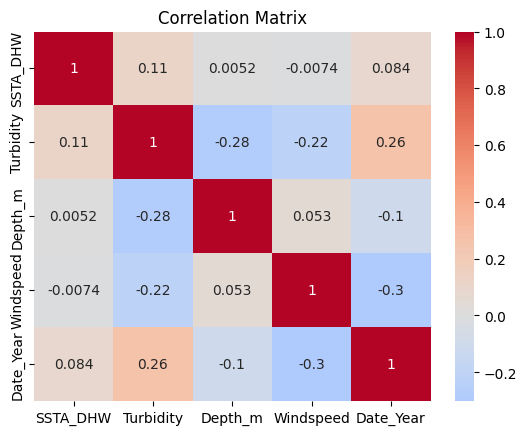

In [50]:
plt.figure()
sns.heatmap(df_cleaned[corr_vars].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

### Ecoregion variation predictors

In [51]:
df_cleaned.groupby("Ecoregion_Name")[
    ["SSTA_DHW", "Turbidity", "Depth_m", "Windspeed"]
].std()

,SSTA_DHW,Turbidity,Depth_m,Windspeed
Ecoregion_Name,,,,
Bahamas and Florida Keys,7.188094,0.045928,4.613884,1.580324
Belize and west Caribbean,2.885553,0.044532,4.626517,1.619235
Central and northern Great Barrier Reef,6.611999,0.056146,1.904627,1.781363
Hispaniola Puerto Rico and Lesser Antilles,4.861831,0.033195,6.405258,1.681060
Jamaica,2.119820,0.023529,2.992881,1.382045
Sulu Sea,2.439840,0.025767,3.183838,1.478963
Sunda Shelf south-east Asia,3.180073,0.073322,2.854691,0.835568


#### Additional checks

In [52]:
# Number of 100% bleaching observations
(df_cleaned["Percent_Bleaching"] == 100).sum()

np.int64(98)